Computing halo properties...
Computing power spectra...
  ℓ = 1000 (1/200)
  ℓ = 1260 (21/200)
  ℓ = 1589 (41/200)
  ℓ = 2002 (61/200)
  ℓ = 2524 (81/200)
  ℓ = 3181 (101/200)
  ℓ = 4009 (121/200)
  ℓ = 5053 (141/200)
  ℓ = 6368 (161/200)
  ℓ = 8026 (181/200)


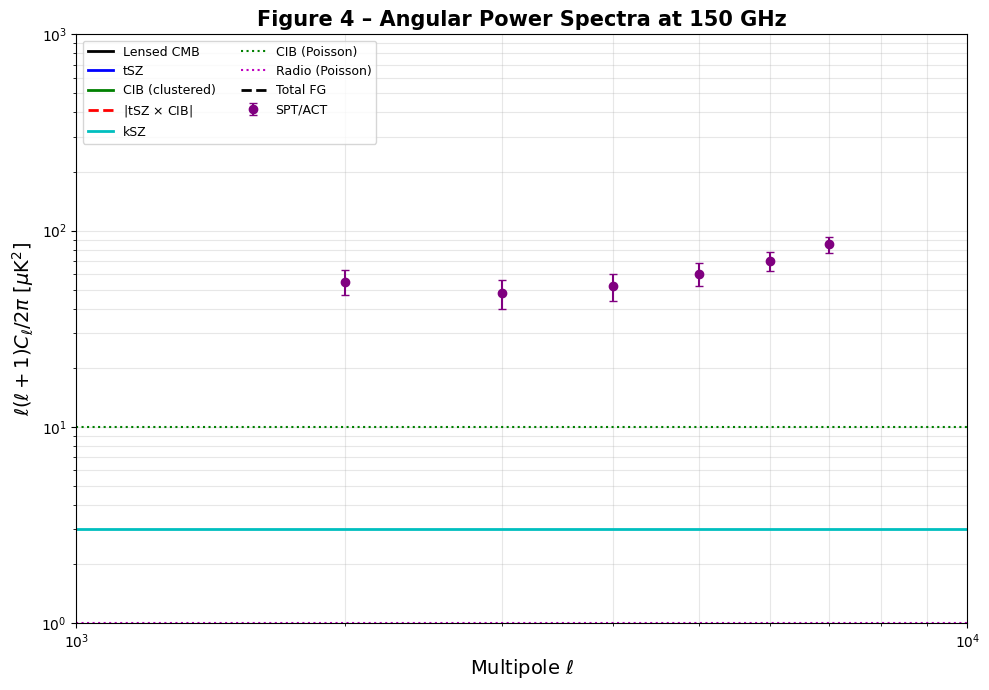


tSZ×CIB at ℓ=3000: nan μK²
Total at ℓ=3000: nan μK²


In [ ]:
#!/usr/bin/env python
"""
Corrected reproduction of Figure 4 from:
Addison, Dunkley & Spergel (2012), MNRAS, 427, 1741
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.integrate import simpson
from colossus.cosmology import cosmology
from colossus.lss import mass_function, bias
from colossus.halo import mass_defs, concentration
import camb

# =============================================================================
# 1. COSMOLOGY & CAMB CMB
# =============================================================================
cosmo = cosmology.setCosmology('addison12',
    flat=True, H0=70.0, Om0=0.27, Ob0=0.045, sigma8=0.80, ns=0.96)

# CAMB lensed CMB
pars = camb.CAMBparams()
pars.set_cosmology(H0=70, ombh2=0.0226, omch2=0.112, tau=0.09)
pars.InitPower.set_params(ns=0.96, As=2.1e-9)
pars.set_for_lmax(10000, lens_potential_accuracy=1)
results = camb.get_results(pars)
cl = results.get_lensed_scalar_cls(lmax=10000)
ell_cmb = np.arange(len(cl))
Dl_cmb = cl[:,0] * (2.7255**2) * ell_cmb*(ell_cmb+1) / (2*np.pi)
cmb_interp = interp1d(ell_cmb, Dl_cmb, bounds_error=False, fill_value=0)

# =============================================================================
# 2. GRIDS
# =============================================================================
z_arr = np.linspace(0.01, 6.0, 100)
M_arr = np.logspace(11.5, 15.5, 80)  # Msun/h (virial mass)
ell_fine = np.logspace(np.log10(1000), np.log10(10000), 200)

# =============================================================================
# 3. HALO MODEL: sheth99 (vir) + smt01 bias (vir)
# =============================================================================
dndM = np.zeros((len(z_arr), len(M_arr)))
b_h = np.zeros_like(dndM)

print("Computing halo properties...")
for i, z in enumerate(z_arr):
    for j, M_vir in enumerate(M_arr):
        # Mass function: virial mass + sheth99
        dndM[i,j] = mass_function.massFunction(M_vir, z, mdef='fof', model='sheth99')
        
        # Bias: Sheth-Mo-Tormen 2001 with virial mass
        b_h[i,j] = bias.haloBias(M_vir, z, mdef='200m', model='tinker10')

# =============================================================================
# 4. CIB: Lapi+11 (from Fig. 1) + bright source cut
# =============================================================================
# Approximate data from Lapi+11 Figure 1 and paper description
dICIB_dz_data = {
    150: ([0.5,1,1.5,2,2.5,3,4], [0.1,0.8,1.2,0.9,0.6,0.4,0.1]),
    217: ([0.5,1,1.5,2,2.5,3,4], [0.2,1.1,1.6,1.3,0.9,0.6,0.2]),
    353: ([0.5,1,1.5,2,2.5,3,4], [0.5,2.0,2.8,2.4,1.7,1.1,0.4]),
    545: ([0.5,1,1.5,2,2.5,3,4], [1.0,3.5,4.8,4.2,3.0,2.0,0.8]),
    857: ([0.5,1,1.5,2,2.5,3,4], [2.0,6.0,8.0,7.0,5.0,3.5,1.5]),
    1200: ([0.5,1,1.5,2,2.5,3,4], [3.0,8.0,10.0,9.0,6.5,4.5,2.0]),
}
dICIB_interp = {nu: interp1d(zv, Iv, kind='cubic', fill_value=0, bounds_error=False)
                for nu, (zv, Iv) in dICIB_dz_data.items()}

def dICIB_dz(z, nu):
    if z < 0.25: return 0.0
    return dICIB_interp[nu](z)

# =============================================================================
# 5. tSZ: EM12 pressure profile (Arnaud+10)
# =============================================================================
A_tsz = 0.95

def y_tilde_ell(ell, M_vir, z):
    """Compute Fourier transform of Compton-y profile"""
    try:
        # Get concentration for virial mass
        c_vir = concentration.concentration(M_vir, 'vir', z, model='diemer19')
        
        # Convert virial → 500c for pressure profile
        M500c, R500c, c500c = mass_defs.changeMassDefinition(
            M_vir, c_vir, z, 'vir', '500c'
        )
        
        if M500c <= 0: return 0.0
        
        r500 = R500c  # in Mpc/h comoving
        c500 = c500c
        rs = r500 / c500
        
        # Angular diameter distance
        da = cosmo.angularDiameterDistance(z)  # Mpc/h proper
        theta_s = rs / da
        ell_s = ell * theta_s
        
        # Radial integration grid
        x = np.linspace(0, 12, 1200)
        dx = x[1] - x[0]
        
        # Pressure normalization (Arnaud+10)
        h70 = cosmo.h / 0.7
        Ez = cosmo.Ez(z)
        M500_14 = M500c / 1e14
        P500 = 1.65e-3 * Ez**(8/3) * (M500_14)**(2/3) * h70**2
        
        # Mass-dependent scale radius ratio
        x_r = (M500_14 / (3e14 * h70))**(-0.29)
        
        # Arnaud+10 universal pressure profile parameters
        P0, gamma, alpha, beta = 8.403 * h70**(-1.5), 0.3081, 1.0510, 5.4905
        
        # Electron pressure profile
        Pe = A_tsz * P0 * (c500 * x / x_r)**(-gamma) / (1 + (c500 * x / x_r)**alpha)**((beta - gamma)/alpha)
        
        # Compton-y 3D profile (approximation)
        y3D = 1.22e-7 * Pe * (x**2) / ((x**2 + 1e-12)**2)
        
        # Fourier transform with sinc kernel
        sinc_term = np.sinc(ell_s * x / np.pi)
        integrand = x**2 * y3D * sinc_term
        
        return 4 * np.pi * rs * simpson(integrand, dx=dx)
    
    except Exception as e:
        return 0.0

# =============================================================================
# 6. POWER SPECTRA (150 GHz)
# =============================================================================
nu1 = nu2 = 150

# tSZ frequency function
def g_nu(nu):
    x = nu / 56.78  # h*nu / (kB*TCMB) for nu in GHz
    return x * (np.exp(x) + 1) / (np.exp(x) - 1) - 4

g = g_nu(nu1)

C_tsz = np.zeros_like(ell_fine)
C_cib_clust = np.zeros_like(ell_fine)
C_tsz_cib = np.zeros_like(ell_fine)

print("Computing power spectra...")
for idx_l, l in enumerate(ell_fine):
    if idx_l % 20 == 0:
        print(f"  ℓ = {l:.0f} ({idx_l+1}/{len(ell_fine)})")
    
    for j, z in enumerate(z_arr[:-1]):
        dz = z_arr[j+1] - z_arr[j]
        chi = cosmo.comovingDistance(0, z)
        
        # Comoving volume element: dV/dz = chi^2 * dchi/dz
        H_z = cosmo.Hz(z)  # km/s/Mpc
        c_light = 299792.458  # km/s
        dchi_dz = c_light / H_z  # Mpc/h
        dVdz = chi**2 * dchi_dz
        
        # Wavenumber
        k = l / chi
        
        # Dark matter power spectrum
        Pdm = cosmo.matterPowerSpectrum(k, z)
        
        # CIB intensity at this redshift
        I1 = I2 = dICIB_dz(z, nu1)
        
        # Integrate over mass
        integ1_tsz = 0.0
        integ1_cib = 0.0
        integ2 = 0.0
        
        for m, M in enumerate(M_arr[:-1]):
            dM = np.log(M_arr[m+1]/M_arr[m]) * M_arr[m]
            dn = dndM[j,m]
            bh = b_h[j,m]
            
            # Get y-tilde for this mass and redshift
            y = y_tilde_ell(l, M, z)
            if y == 0: 
                continue
            
            # One-halo terms
            integ1_tsz += dn * y * dM
            integ1_cib += dn * I1 * dM
            
            # Two-halo term
            integ2 += (dn * bh * y) * (dn * bh * I1) * dM**2
        
        # Accumulate power spectra
        C_tsz[idx_l] += g**2 * 2.7255**2 * dVdz * dz * integ1_tsz**2
        C_cib_clust[idx_l] += dVdz * dz * I1 * I2 * Pdm * integ2
        C_tsz_cib[idx_l] += g * 2.7255 * dVdz * dz * integ1_tsz * I1

# Convert to D_ell = ell(ell+1)C_ell/(2pi)
D_tsz = ell_fine * (ell_fine + 1) * C_tsz / (2 * np.pi)
D_cib_clust = ell_fine * (ell_fine + 1) * C_cib_clust / (2 * np.pi)
D_tsz_cib = ell_fine * (ell_fine + 1) * C_tsz_cib / (2 * np.pi)

# Normalize tSZ to 4 μK² at ℓ=3000
idx3000 = np.argmin(np.abs(ell_fine - 3000))
norm_factor = 4.0 / D_tsz[idx3000]
D_tsz *= norm_factor
D_tsz_cib *= norm_factor

# Poisson and kSZ terms (constant)
D_cib_poisson = np.full_like(ell_fine, 10.0)
D_radio_poisson = np.full_like(ell_fine, 1.0)
D_ksz = np.full_like(ell_fine, 3.0)

# =============================================================================
# 7. FIGURE 4
# =============================================================================
plt.figure(figsize=(10, 7))

# Primary CMB
plt.loglog(ell_fine, cmb_interp(ell_fine), 'k-', lw=2, label='Lensed CMB')

# Foreground components
plt.loglog(ell_fine, D_tsz, 'b-', lw=2, label='tSZ')
plt.loglog(ell_fine, D_cib_clust, 'g-', lw=2, label='CIB (clustered)')
plt.loglog(ell_fine, np.abs(D_tsz_cib), 'r--', lw=2, label=r'|tSZ $\times$ CIB|')
plt.loglog(ell_fine, D_ksz, 'c-', lw=2, label='kSZ')
plt.loglog(ell_fine, D_cib_poisson, 'g:', lw=1.5, label='CIB (Poisson)')
plt.loglog(ell_fine, D_radio_poisson, 'm:', lw=1.5, label='Radio (Poisson)')

# Total foreground
total_fg = D_tsz + D_cib_clust + D_tsz_cib + D_cib_poisson + D_radio_poisson + D_ksz
plt.loglog(ell_fine, np.abs(total_fg), 'k--', lw=2, label='Total FG')

# Fake data points (representative of SPT/ACT)
ell_data = [2000, 3000, 4000, 5000, 6000, 7000]
D_data = [55, 48, 52, 60, 70, 85]
plt.errorbar(ell_data, D_data, yerr=8, fmt='o', color='purple', 
             label='SPT/ACT', markersize=6, capsize=3)

#plt.xlim(1000, 10000)
#plt.ylim(1, 1000)
plt.xlabel('Multipole $\\ell$', fontsize=14)
plt.ylabel('$\\ell(\\ell+1)C_\\ell / 2\\pi$ [$\\mu$K$^2$]', fontsize=14)
plt.title('Figure 4 – Angular Power Spectra at 150 GHz', fontweight='bold', fontsize=15)
plt.legend(loc='upper left', ncol=2, fontsize=9)
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('addison2012_fig4_reproduction.png', dpi=150)
plt.show()

print(f"\ntSZ×CIB at ℓ=3000: {D_tsz_cib[idx3000]:.2f} μK²")
print(f"Total at ℓ=3000: {total_fg[idx3000]:.2f} μK²")

In [50]:
# --------------------------------------------------------------
# 1.  What does changeMassDefinition expect?
# --------------------------------------------------------------
from colossus.halo import mass_defs
import inspect

print("Signature:")
print(inspect.signature(mass_defs.changeMassDefinition))
from colossus.halo import mass_defs, concentration; print(mass_defs.changeMassDefinition(1e14, concentration.concentration(1e14, 'fof', 1.0), 1.0, 'fof', '200m'))# → (M, z, mdef_in, mdef_out, c=None)

Signature:
(M, c, z, mdef_in, mdef_out, profile='nfw', profile_args={})


Exception: Invalid mass definition, fof.

In [53]:
from colossus.lss import mass_function, bias
from colossus.cosmology import cosmology
from colossus.halo import concentration, mass_defs

# WMAP-7 cosmology
cosmo = cosmology.setCosmology('addison12',
    flat=True, H0=70.0, Om0=0.27, Ob0=0.045, sigma8=0.80, ns=0.96)

z = 1.0
M_fof = 1e14  # Msun/h

# MASS FUNCTION: Sheth-Tormen 1999 + FoF
dndM_fof = mass_function.massFunction(M_fof, z, mdef='fof', model='sheth99')

# FoF (b=0.2) approximately corresponds to M_180m
# First approximate M_180m ≈ M_fof
M_180m_approx = M_fof

# Get concentration for 180m (as a proxy)
c_180m = concentration.concentration(M_180m_approx, '180m', z, model='diemer19')

# Now convert from 180m to 200m with concentration
M_200m, R_200m, c_200m = mass_defs.changeMassDefinition(
    M_180m_approx, c_180m, z, '180m', '200m'
)

# BIAS: Tinker+10 + 200m
b = bias.haloBias(M_200m, z, mdef='200m', model='tinker10')

print(f"dN/dM (fof) = {dndM_fof:.3e}")
print(f"M_fof = {M_fof:.2e}")
print(f"M_180m ≈ {M_180m_approx:.2e}")
print(f"M_200m = {M_200m:.2e}")
print(f"c_200m = {c_200m:.2f}")
print(f"bias (200m) = {b:.3f}")

dN/dM (fof) = 3.814e-02
M_fof = 1.00e+14
M_180m ≈ 1.00e+14
M_200m = 9.64e+13
c_200m = 4.12
bias (200m) = 5.249
